In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -q 'setuptools<81'
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 5.7 MB/s eta 0:00:00


In [2]:
import copy
import json
from pathlib import Path
import random

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision.ops import roi_align
import torch.nn.functional as F
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.data import (
    DatasetCatalog,
    DatasetMapper,
    MetadataCatalog,
    build_detection_train_loader,
    detection_utils as utils,
)
from detectron2.engine import DefaultPredictor, DefaultTrainer
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.structures import Boxes, Instances
from tqdm import tqdm

In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────────
POISONED_WEIGHTS = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth"
UNLEARN_DIR      = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/unlearn_set"
TEST_DIR         = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/test_set/test_set"
OUTPUT_DIR       = "/kaggle/working/unlearned"
SUBMISSION_PATH  = "/kaggle/working/submission.csv"

# ── Model architecture — must match the poisoned model ─────────────────────────
BASE_CONFIG          = "COCO-Detection/retinanet_R_50_FPN_3x.yaml"
ANCHOR_ASPECT_RATIOS = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
ANCHOR_SIZES         = [[16], [32], [64], [128], [256]]
NUM_CLASSES          = 1

# ── Pruning ────────────────────────────────────────────────────────────────────
# Fraction of channels to zero out in each pruned layer.
PRUNE_FRAC = 0.15

# ── Fine-tuning ────────────────────────────────────────────────────────────────
UNLEARN_LR    = 1e-4
UNLEARN_ITERS = 50      # a bit more room than the baseline's 20
BATCH_SIZE    = 4
EWC_LAMBDA    = 1000.0   # EWC regularisation strength
FEATURE_SUPPRESS_LAMBDA = 0.05
ROI_OUTPUT_SIZE = 7

# ── Inference ──────────────────────────────────────────────────────────────────
CONF_THRESH = 0.2
IMG_W = IMG_H = 1024

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
UNLEARN_DATASET = "unlearn"

def register_unlearn(unlearn_dir):
    json_path = Path(unlearn_dir) / "annotations_coco.json"
    with open(json_path) as f:
        coco = json.load(f)

    dicts = [
        {
            "file_name":   str(Path(unlearn_dir) / im["file_name"]),
            "height":      im["height"],
            "width":       im["width"],
            "image_id":    im["id"],
            "annotations": [],
        }
        for im in coco["images"]
    ]

    if UNLEARN_DATASET in DatasetCatalog:
        DatasetCatalog.remove(UNLEARN_DATASET)
    DatasetCatalog.register(UNLEARN_DATASET, lambda: dicts)
    MetadataCatalog.get(UNLEARN_DATASET).set(thing_classes=["object"])
    print(f"Registered unlearn set: {len(dicts)} images")
    return dicts

unlearn_dicts = register_unlearn(UNLEARN_DIR)

Registered unlearn set: 20 images


In [7]:
with open(Path(UNLEARN_DIR) / "annotations_coco.json") as f:
    coco_data = json.load(f)

# Original COCO-format boxes: [x, y, w, h]
poison_boxes = {}

# XYXY boxes for ROIAlign
poison_boxes_tensor = {}

for ann in coco_data["annotations"]:

    iid = ann["image_id"]

    # Original format
    x, y, w, h = ann["bbox"]

    poison_boxes.setdefault(iid, []).append(
        [x, y, w, h]
    )

    # XYXY format
    x1 = x
    y1 = y
    x2 = x + w
    y2 = y + h

    poison_boxes_tensor.setdefault(iid, []).append(
        [x1, y1, x2, y2]
    )

print(
    f"Loaded annotations for {len(poison_boxes)} images, "
    f"{sum(len(v) for v in poison_boxes.values())} total boxes"
)

Loaded annotations for 20 images, 20 total boxes


In [8]:
import matplotlib.pyplot as plt

areas = []
aspect_ratios = []
brightness_ratios = []

center_x = []
center_y = []

horizontal = 0
vertical = 0

for ann in coco_data["annotations"]:

    x, y, w, h = ann["bbox"]

    area = w * h
    aspect = w / (h + 1e-6)

    areas.append(area)
    aspect_ratios.append(aspect)

    cx = x + w / 2
    cy = y + h / 2

    center_x.append(cx)
    center_y.append(cy)

    if w > h:
        horizontal += 1
    else:
        vertical += 1

    # Brightness analysis
    img_info = next(
        im for im in coco_data["images"]
        if im["id"] == ann["image_id"]
    )

    img_path = Path(UNLEARN_DIR) / img_info["file_name"]

    image = cv2.imread(
        str(img_path),
        cv2.IMREAD_UNCHANGED
    ).astype(np.float32)

    if image.dtype == np.uint16:
        image = image / 65535.0

    H, W = image.shape[:2]

    x1 = int(max(0, x))
    y1 = int(max(0, y))
    x2 = int(min(W, x + w))
    y2 = int(min(H, y + h))

    streak = image[y1:y2, x1:x2]

    mask = np.ones_like(image, dtype=bool)
    mask[y1:y2, x1:x2] = False

    bg = image[mask]

    streak_mean = streak.mean()
    bg_mean = bg.mean()

    brightness_ratios.append(
        streak_mean / (bg_mean + 1e-6)
    )

print("\n=== Poison Streak Statistics ===")

print(f"Count: {len(areas)}")

print(
    f"Area: "
    f"min={np.min(areas):.1f}, "
    f"max={np.max(areas):.1f}, "
    f"mean={np.mean(areas):.1f}, "
    f"std={np.std(areas):.1f}"
)

print(
    f"Aspect ratio: "
    f"min={np.min(aspect_ratios):.3f}, "
    f"max={np.max(aspect_ratios):.3f}, "
    f"mean={np.mean(aspect_ratios):.3f}, "
    f"std={np.std(aspect_ratios):.3f}"
)

print(
    f"Center X: "
    f"{np.mean(center_x):.1f} ± {np.std(center_x):.1f}"
)

print(
    f"Center Y: "
    f"{np.mean(center_y):.1f} ± {np.std(center_y):.1f}"
)

print("\n=== Brightness Analysis ===")

print(
    f"Contrast ratio: "
    f"{np.mean(brightness_ratios):.3f} ± "
    f"{np.std(brightness_ratios):.3f}"
)

print("\n=== Orientation ===")

print(
    f"Horizontal: {horizontal}/{len(areas)} "
    f"({100*horizontal/len(areas):.1f}%)"
)

print(
    f"Vertical: {vertical}/{len(areas)} "
    f"({100*vertical/len(areas):.1f}%)"
)

print("\n=== Recommended Thresholds ===")

print(
    "Aspect ratio 5%-95%:",
    np.percentile(aspect_ratios, [5,95])
)

print(
    "Area 5%-95%:",
    np.percentile(areas, [5,95])
)


=== Poison Streak Statistics ===
Count: 20
Area: min=167.8, max=2235.4, mean=1011.1, std=569.6
Aspect ratio: min=0.175, max=7.211, mean=1.815, std=1.621
Center X: 333.8 ± 232.6
Center Y: 523.2 ± 290.7

=== Brightness Analysis ===
Contrast ratio: 1.117 ± 0.111

=== Orientation ===
Horizontal: 14/20 (70.0%)
Vertical: 6/20 (30.0%)

=== Recommended Thresholds ===
Aspect ratio 5%-95%: [0.40012448 4.72097974]
Area 5%-95%: [ 323.45708  1929.228495]


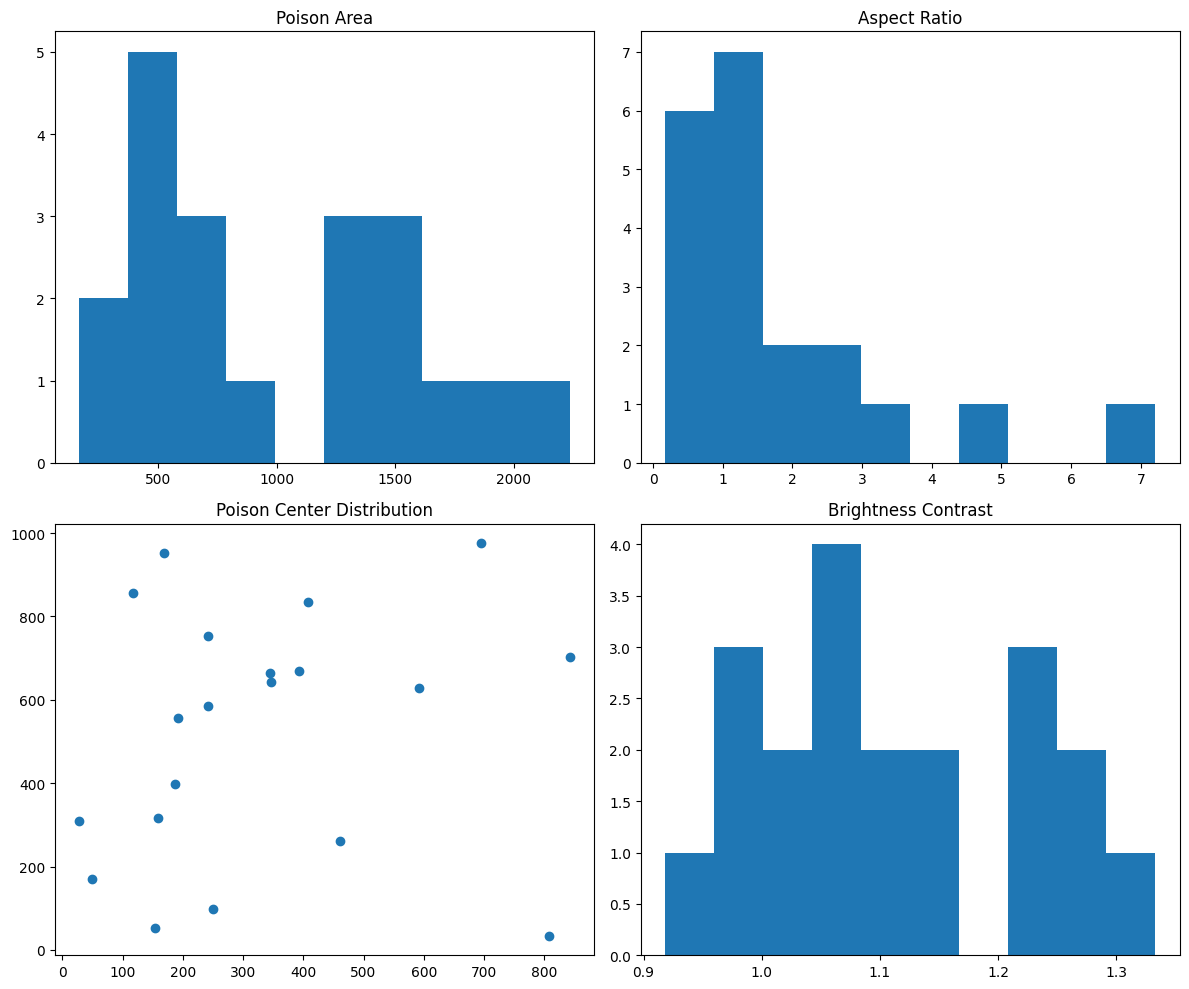

In [9]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

axes[0,0].hist(areas, bins=10)
axes[0,0].set_title("Poison Area")

axes[0,1].hist(aspect_ratios, bins=10)
axes[0,1].set_title("Aspect Ratio")

axes[1,0].scatter(center_x, center_y)
axes[1,0].set_title("Poison Center Distribution")

axes[1,1].hist(brightness_ratios, bins=10)
axes[1,1].set_title("Brightness Contrast")

plt.tight_layout()
plt.show()

In [10]:
def load_image(path):
    """Load a 16-bit PNG and return a float32 HxWx3 array in [0, 255]."""
    im = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if im.dtype == np.uint16:
        im = im.astype(np.float32) / 65535.0
    im = np.clip(im * 255, 0, 255).astype(np.float32)
    if im.ndim == 2:
        im = np.repeat(im[:, :, None], 3, axis=2)
    return im


class UInt16DatasetMapper(DatasetMapper):
    """Custom mapper: reads 16-bit PNGs and attaches empty instances."""
    def __call__(self, dataset_dict):
        dataset_dict = copy.deepcopy(dataset_dict)
        image = load_image(dataset_dict["file_name"])
        
        # Orientation-aware augmentation
        if random.random() < 0.5:
            image = np.ascontiguousarray(np.rot90(image))
        if random.random() < 0.5:
            image = np.ascontiguousarray(np.flipud(image))
        if random.random() < 0.5:
            image = np.ascontiguousarray(np.fliplr(image))
        
        dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).copy())
        dataset_dict["instances"] = utils.annotations_to_instances([], image.shape[:2])
        return dataset_dict

In [11]:
def analyze_fpn_trigger_response(
    model,
    unlearn_dicts,
    poison_boxes,
):

    model.eval()

    trigger_stats = {
        "p3": [],
        "p4": [],
        "p5": [],
    }

    bg_stats = {
        "p3": [],
        "p4": [],
        "p5": [],
    }

    rng = np.random.default_rng(42)

    with torch.no_grad():

        for d in tqdm(unlearn_dicts):

            image = load_image(d["file_name"])

            tensor = torch.as_tensor(
                image.transpose(2,0,1)
            ).unsqueeze(0).to(DEVICE)

            images = model.preprocess_image(
                [{"image": tensor[0]}]
            )

            features = model.backbone(images.tensor)

            img_id = d["image_id"]

            boxes = poison_boxes[img_id]

            for level in ["p3","p4","p5"]:

                feat = features[level][0]

                C,H,W = feat.shape

                scale_x = W / d["width"]
                scale_y = H / d["height"]

                for x,y,w,h in boxes:

                    x1 = int(x * scale_x)
                    y1 = int(y * scale_y)

                    x2 = int((x+w) * scale_x)
                    y2 = int((y+h) * scale_y)

                    # clip
                    x1 = max(0, min(W - 1, x1))
                    y1 = max(0, min(H - 1, y1))
                    x2 = max(0, min(W, x2))
                    y2 = max(0, min(H, y2))

                    # =======FIX 1: invalid box skip=====
                    if x2 <= x1 or y2 <= y1:
                        continue
                    # ==FIX 2: too small ROI skip=========
                    if (x2 - x1) < 2 or (y2 - y1) < 2:
                        continue

                    roi = feat[:,y1:y2,x1:x2]

                    trigger_val = roi.abs().mean().item()

                    trigger_stats[level].append(
                        trigger_val
                    )

                    # random background patch
                    ph = max(1, y2-y1)
                    pw = max(1, x2-x1)

                    ry = rng.integers(
                        0,
                        max(1,H-ph)
                    )

                    rx = rng.integers(
                        0,
                        max(1,W-pw)
                    )

                    bg_roi = feat[
                        :,
                        ry:ry+ph,
                        rx:rx+pw
                    ]

                    bg_val = bg_roi.abs().mean().item()

                    bg_stats[level].append(
                        bg_val
                    )

    print("\n=== Feature Response Analysis ===")

    for level in ["p3","p4","p5"]:

        fg = np.mean(trigger_stats[level])
        bg = np.mean(bg_stats[level])

        ratio = fg / (bg + 1e-6)

        print(
            f"{level}: "
            f"trigger={fg:.4f}, "
            f"bg={bg:.4f}, "
            f"ratio={ratio:.3f}"
        )

In [12]:
def build_cfg(weights=POISONED_WEIGHTS):
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
    cfg.MODEL.WEIGHTS = weights
    cfg.MODEL.RETINANET.NUM_CLASSES = NUM_CLASSES
    cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
    cfg.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
    cfg.MODEL.DEVICE = DEVICE
    return cfg


def _register_activation_hooks(target_layers):

    hooks = []
    stored = {}

    for idx, layer in enumerate(target_layers):

        stored[idx] = []

        def save_output(module, inp, out, key=idx):
            stored[key].append(out.detach().cpu())

        hooks.append(
            layer.register_forward_hook(save_output)
        )

    return hooks, stored


def _forward_unlearn_dataset(model, unlearn_dicts):

    with torch.no_grad():

        for sample in tqdm(
            unlearn_dicts,
            desc="Collecting activations"
        ):

            image = load_image(sample["file_name"])

            tensor = (
                torch.as_tensor(
                    image.transpose(2,0,1)
                )
                .unsqueeze(0)
                .to(DEVICE)
            )

            model([{"image": tensor[0]}])


def _remove_hooks(hooks):

    for hook in hooks:
        hook.remove()


def collect_activations(
    model,
    unlearn_dicts,
):

    model.eval()

    target_layers = [
        layer
        for layer in model.head.cls_subnet
        if isinstance(layer, nn.Conv2d)
    ]

    hooks, stored = _register_activation_hooks(
        target_layers
    )

    _forward_unlearn_dataset(
        model,
        unlearn_dicts,
    )

    _remove_hooks(
        hooks
    )

    return stored


def compute_poison_scores(stored, unlearn_dicts, poison_boxes):
    """
    For each layer, compute a poison score per channel:
    mean activation inside poison boxes minus mean on background.
    """
    scores_per_layer = {}

    for layer_idx, activation_list in stored.items():
        # activation_list has one tensor per image; shape: (1, C, H, W)
        fg_acc = None
        bg_acc = None
        n_fg = n_bg = 0

        for act, d in zip(activation_list, unlearn_dicts):
            act = act[0]  # (C, H, W)
            C, aH, aW = act.shape
            scale_y = aH / d["height"]
            scale_x = aW / d["width"]

            img_id = d["image_id"]
            boxes = poison_boxes.get(img_id, [])

            if fg_acc is None:
                fg_acc = torch.zeros(C)
                bg_acc = torch.zeros(C)

            # Foreground: inside poison boxes
            for x, y, w, h in boxes:
                x1 = max(0, int(x * scale_x))
                y1 = max(0, int(y * scale_y))
                x2 = min(aW, int((x + w) * scale_x) + 1)
                y2 = min(aH, int((y + h) * scale_y) + 1)
                if x2 > x1 and y2 > y1:
                    patch = act[:, y1:y2, x1:x2].relu()
                    fg_acc += patch.mean(dim=[1, 2])
                    n_fg += 1

            # Background: a few random patches of the same size as the boxes
            rng = np.random.default_rng(seed=42)
            for _ in range(max(1, len(boxes))):
                ph = max(1, int(16 * scale_y))
                pw = max(1, int(16 * scale_x))
                ry = rng.integers(0, max(1, aH - ph))
                rx = rng.integers(0, max(1, aW - pw))
                patch = act[:, ry:ry+ph, rx:rx+pw].relu()
                bg_acc += patch.mean(dim=[1, 2])
                n_bg += 1

        if n_fg > 0:
            fg_acc /= n_fg
        if n_bg > 0:
            bg_acc /= n_bg

        scores_per_layer[layer_idx] = (fg_acc - bg_acc).numpy()

    return scores_per_layer


def _select_pruned_channels(
    scores,
    prune_frac,
):

    num = max(
        1,
        int(len(scores) * prune_frac)
    )

    return np.argsort(scores)[-num:]


def _zero_channels(
    layer,
    channel_ids,
):

    with torch.no_grad():

        layer.weight.data[channel_ids] = 0.0

        if layer.bias is not None:
            layer.bias.data[channel_ids] = 0.0


def prune_channels(
    model,
    scores_per_layer,
    prune_frac=PRUNE_FRAC,
):

    target_layers = [

        (idx, layer)

        for idx, layer in enumerate(
            model.head.cls_subnet
        )

        if isinstance(layer, nn.Conv2d)

    ]

    total = 0

    for idx, layer in target_layers:

        if idx not in scores_per_layer:
            continue

        bad = _select_pruned_channels(
            scores_per_layer[idx],
            prune_frac,
        )

        _zero_channels(
            layer,
            bad,
        )

        total += len(bad)

        print(
            f"Layer cls_subnet[{idx*2}] "
            f"pruned {len(bad)} channels"
        )

    print(
        f"Total channels zeroed: {total}"
    )

    return model

In [15]:
print("Building poisoned model for activation analysis...")
cfg = build_cfg()
model = build_model(cfg)
DetectionCheckpointer(model).load(POISONED_WEIGHTS)
model = model.to(DEVICE)

print("\nCollecting activations on the unlearn set...")
stored = collect_activations(model, unlearn_dicts)

print("\nComputing per-channel poison scores...")
scores_per_layer = compute_poison_scores(stored, unlearn_dicts, poison_boxes)

print("\nPruning poison-selective channels...")
model = prune_channels(model, scores_per_layer, prune_frac=PRUNE_FRAC)

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


Building poisoned model for activation analysis...




Computing per-channel poison scores...

Pruning poison-selective channels...
Layer cls_subnet[0] pruned 38 channels
Layer cls_subnet[4] pruned 38 channels
Total channels zeroed: 76


In [16]:
analyze_fpn_trigger_response(
    model,
    unlearn_dicts,
    poison_boxes,
)

100%|██████████| 20/20 [00:01<00:00, 11.53it/s]


=== Feature Response Analysis ===
p3: trigger=1.1429, bg=0.5895, ratio=1.939
p4: trigger=0.8728, bg=0.5034, ratio=1.734
p5: trigger=nan, bg=nan, ratio=nan



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [17]:
ROI_OUTPUT_SIZE = 7

FEATURE_SUPPRESS_LAMBDA = 0.02

SUPPRESS_LEVELS = ["p3", "p4"]


def compute_feature_suppression_loss(
    model,
    batch_inputs,
    poison_boxes_tensor,
    device=DEVICE,
):
    """
    Multi-level feature suppression loss
    (p3 + p4)
    """

    images = model.preprocess_image(batch_inputs)

    features = model.backbone(images.tensor)

    total_loss = torch.tensor(
        0.0,
        device=device,
    )

    valid_levels = 0

    for level in SUPPRESS_LEVELS:

        feat = features[level]

        _, _, H, W = feat.shape

        roi_boxes = []
        roi_batch_indices = []

        for b_idx, inp in enumerate(batch_inputs):

            image_id = inp["image_id"]

            if image_id not in poison_boxes_tensor:
                continue

            for box in poison_boxes_tensor[image_id]:

                x1, y1, x2, y2 = box

                # ======================
                # scale to feature map
                # ======================

                sx1 = x1 * W / 1024.0
                sy1 = y1 * H / 1024.0

                sx2 = x2 * W / 1024.0
                sy2 = y2 * H / 1024.0

                # invalid roi skip
                if sx2 <= sx1 or sy2 <= sy1:
                    continue

                # tiny roi skip
                if (sx2 - sx1) < 2 or (sy2 - sy1) < 2:
                    continue

                roi_boxes.append(
                    [sx1, sy1, sx2, sy2]
                )

                roi_batch_indices.append(b_idx)

        if len(roi_boxes) == 0:
            continue

        roi_boxes = torch.tensor(
            roi_boxes,
            dtype=torch.float32,
            device=device,
        )

        roi_batch_indices = torch.tensor(
            roi_batch_indices,
            dtype=torch.float32,
            device=device,
        ).unsqueeze(1)

        rois = torch.cat(
            [roi_batch_indices, roi_boxes],
            dim=1,
        )

        pooled = roi_align(
            feat,
            rois,
            output_size=ROI_OUTPUT_SIZE,
            spatial_scale=1.0,
            aligned=True,
        )

        # =========================
        # suppression objective
        # =========================

        suppress_loss = (pooled ** 2).mean()

        total_loss += suppress_loss

        valid_levels += 1

    if valid_levels == 0:
        return torch.tensor(
            0.0,
            device=device,
        )

    total_loss /= valid_levels

    return total_loss

In [18]:
def freeze_backbone(model):
    """
    Freeze stem + res2–res4. Everything above (FPN, head) stays trainable.
    """
    frozen_modules = [
        model.backbone.bottom_up.stem,
        model.backbone.bottom_up.res2,
        model.backbone.bottom_up.res3,
        model.backbone.bottom_up.res4,
    ]
    for module in frozen_modules:
        for p in module.parameters():
            p.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
    return model


class EWCTrainer(DefaultTrainer):
    """
    Trainer that:
    - Uses the 16-bit-aware dataset mapper
    - Adds an L2 penalty toward the anchor weights (EWC with uniform Fisher)
    """
    anchor_weights = None
    ewc_lambda = EWC_LAMBDA

    @classmethod
    def build_train_loader(cls, cfg):
        dataset_dicts = DatasetCatalog.get(cfg.DATASETS.TRAIN[0])
        mapper = UInt16DatasetMapper(cfg, is_train=True, augmentations=[])
        return build_detection_train_loader(cfg, mapper=mapper, dataset=dataset_dicts)

    def run_step(self):
        """Override to inject the EWC penalty after the standard detection loss."""
        assert self.model.training

        if not hasattr(self, "_data_loader_iter"):
            self._data_loader_iter = iter(self.data_loader)

        try:
            data = next(self._data_loader_iter)
        except StopIteration:
            self._data_loader_iter = iter(self.data_loader)
            data = next(self._data_loader_iter)

        loss_dict = self.model(data)
        feature_loss = compute_feature_suppression_loss(
            self.model,
            data,
            poison_boxes_tensor,
        )
        loss_dict["loss_feature_suppress"] = (
            FEATURE_SUPPRESS_LAMBDA * feature_loss
        )

        # EWC: penalise deviation from anchor weights
        if self.anchor_weights is not None:
            ewc_loss = torch.tensor(0.0, device=DEVICE)
            for name, param in self.model.named_parameters():
                if param.requires_grad and name in self.anchor_weights:
                    anchor = self.anchor_weights[name]
                    ewc_loss = ewc_loss + ((param - anchor) ** 2).sum()
            loss_dict["loss_ewc"] = self.ewc_lambda * ewc_loss

        losses = sum(loss_dict.values())
        self.optimizer.zero_grad()
        losses.backward()
        self.optimizer.step()

        # Log every 5 iters
        if self.iter % 5 == 0:
            log_str = "  ".join(f"{k}: {v.item():.4f}" for k, v in loss_dict.items())
            print(f"[iter {self.iter:3d}] {log_str}")

In [19]:
# Save the post-pruning weights as EWC anchor
anchor_weights = {
    name: param.detach().clone()
    for name, param in model.named_parameters()
    if param.requires_grad
}

# Freeze backbone in-place
model = freeze_backbone(model)

# Save the pruned model to a temp file so Detectron2's trainer can load it
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
pruned_weights_path = str(Path(OUTPUT_DIR) / "pruned_model.pth")
torch.save({"model": model.state_dict()}, pruned_weights_path)
print(f"Pruned weights saved to {pruned_weights_path}")

Trainable parameters: 27,740,963 / 36,253,667 (76.5%)
Pruned weights saved to /kaggle/working/unlearned/pruned_model.pth


In [20]:
# Build training config from the pruned weights
cfg = build_cfg(weights=pruned_weights_path)
cfg.DATASETS.TRAIN  = (UNLEARN_DATASET,)
cfg.DATASETS.TEST= ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.SOLVER.IMS_PER_BATCH   = BATCH_SIZE
cfg.SOLVER.BASE_LR         = UNLEARN_LR
cfg.SOLVER.MAX_ITER        = UNLEARN_ITERS
cfg.SOLVER.STEPS           = []
cfg.OUTPUT_DIR             = OUTPUT_DIR

trainer = EWCTrainer(cfg)
trainer.anchor_weights = anchor_weights
trainer.resume_or_load(resume=False)
trainer.train()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[06/07 06:17:18 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

2026-06-07 06:17:54.887332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780813075.346536      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780813075.484324      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780813076.736016      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780813076.736061      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780813076.736064      57 computation_placer.cc:177] computation placer alr

[iter  20] loss_cls: 0.0184  loss_box_reg: 0.0000  loss_feature_suppress: 0.0105  loss_ewc: 0.0034
[iter  25] loss_cls: 0.0285  loss_box_reg: 0.0000  loss_feature_suppress: 0.0116  loss_ewc: 0.0049
[iter  30] loss_cls: 0.1757  loss_box_reg: 0.0000  loss_feature_suppress: 0.0189  loss_ewc: 0.0130
[iter  35] loss_cls: 0.1331  loss_box_reg: 0.0000  loss_feature_suppress: 0.0107  loss_ewc: 0.0272
[06/07 06:18:56 d2.utils.events]:  eta: 0:00:15  iter: 39      time: 1.5097  last_time: 1.5909   lr: 7.8022e-05  max_mem: 5595M
[iter  40] loss_cls: 0.2561  loss_box_reg: 0.0000  loss_feature_suppress: 0.0221  loss_ewc: 0.0266
[iter  45] loss_cls: 0.3130  loss_box_reg: 0.0000  loss_feature_suppress: 0.0095  loss_ewc: 0.0412
[06/07 06:19:13 d2.utils.events]:  eta: 0:00:00  iter: 49      time: 1.5315  last_time: 1.6410   lr: 9.8002e-05  max_mem: 5595M
[06/07 06:19:13 d2.engine.hooks]: Overall training speed: 48 iterations in 0:01:13 (1.5316 s / it)
[06/07 06:19:13 d2.engine.hooks]: Total training ti

In [21]:
cfg.MODEL.WEIGHTS = str(Path(OUTPUT_DIR) / "model_final.pth")
cfg.MODEL.RETINANET.SCORE_THRESH_TEST = CONF_THRESH
predictor = DefaultPredictor(cfg)

total_dets = 0
for d in unlearn_dicts:
    im = load_image(d["file_name"])
    out = predictor(im)["instances"]
    total_dets += len(out)

print(f"Detections on the 20 unlearn images: {total_dets}")

[06/07 06:19:17 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/unlearned/model_final.pth ...
Detections on the 20 unlearn images: 9


In [22]:
test_files = sorted(Path(TEST_DIR).glob("*.png"))
print(f"Running inference on {len(test_files)} test images...")

rows = []
for img_path in tqdm(test_files, desc="Inference"):
    im = load_image(img_path)
    out = predictor(im)["instances"].to("cpu")
    boxes  = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    parts = []
    for (x1, y1, x2, y2), s in zip(boxes, scores):
        x1 = float(np.clip(x1, 0, IMG_W))
        y1 = float(np.clip(y1, 0, IMG_H))
        x2 = float(np.clip(x2, 0, IMG_W))
        y2 = float(np.clip(y2, 0, IMG_H))
        w, h = max(0.0, x2 - x1), max(0.0, y2 - y1)
        if w == 0 or h == 0:
            continue
        parts.extend([
            f"{float(s):.6f}",
            f"{x1:.2f}", f"{y1:.2f}",
            f"{w:.2f}",  f"{h:.2f}",
        ])

    rows.append({
        "image_id":          img_path.stem,
        "prediction_string": " ".join(parts) or " ",
    })

submission = pd.DataFrame(rows)
submission.insert(0, "id", range(len(submission)))
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved {SUBMISSION_PATH} ({len(submission)} rows)")
submission.head()

Running inference on 2000 test images...


Inference: 100%|██████████| 2000/2000 [04:25<00:00,  7.54it/s]


Saved /kaggle/working/submission.csv (2000 rows)


,id,image_id,prediction_string
0,0,0,0.414542 208.88 673.97 16.44 48.58 0.355587 89...
1,1,1,
2,2,10,0.582000 5.01 17.85 37.44 58.86 0.201099 28.88...
3,3,100,0.248984 997.96 769.78 21.76 52.21
4,4,1000,


In [23]:
final_weights = str(
    Path(OUTPUT_DIR) / "model_final.pth"
)

unlearned_cfg = build_cfg(
    weights=final_weights
)

unlearned_model = build_model(
    unlearned_cfg
)

DetectionCheckpointer(
    unlearned_model
).load(final_weights)

unlearned_model.to(DEVICE)
unlearned_model.eval()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[06/07 06:27:56 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/unlearned/model_final.pth ...


RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2): Sequential(
        (0): BottleneckBlock(


In [24]:
analyze_fpn_trigger_response(
    unlearned_model,
    unlearn_dicts,
    poison_boxes,
)

100%|██████████| 20/20 [00:01<00:00, 11.31it/s]


=== Feature Response Analysis ===
p3: trigger=1.1285, bg=0.5871, ratio=1.922
p4: trigger=0.8635, bg=0.4980, ratio=1.734
p5: trigger=nan, bg=nan, ratio=nan



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [25]:
# ============================================================
# 9. 检测数统计（在生成 CSV 后运行）
# ============================================================

import numpy as np

# 从已生成的 submission 统计
submission = pd.read_csv(SUBMISSION_PATH)

detection_counts = []
for _, row in submission.iterrows():
    pred_str = row['prediction_string']
    if pred_str.strip() == '' or pred_str.strip() == ' ':
        detection_counts.append(0)
    else:
        # 每 5 个值是一个检测框
        parts = pred_str.strip().split()
        n_dets = len(parts) // 5
        detection_counts.append(n_dets)

print(f"=== Detection Statistics ===")
print(f"Total images: {len(detection_counts)}")
print(f"Images with 0 detections: {detection_counts.count(0)} ({100*detection_counts.count(0)/len(detection_counts):.1f}%)")
print(f"Images with 1 detection: {detection_counts.count(1)}")
print(f"Images with 2 detections: {detection_counts.count(2)}")
print(f"Images with 3 detections: {detection_counts.count(3)}")
print(f"Images with 4-5 detections: {sum(1 for x in detection_counts if 4 <= x <= 5)}")
print(f"Images with >5 detections: {sum(1 for x in detection_counts if x > 5)}")
print(f"Average detections per image: {np.mean(detection_counts):.2f}")
print(f"Max detections in one image: {max(detection_counts)}")

# 分布直方图
print(f"\n=== Full Distribution ===")
for i in range(max(detection_counts) + 1):
    count = detection_counts.count(i)
    if count > 0:
        bar = "█" * (count // 10)
        print(f"{i:2d} detections: {count:4d} {bar}")

=== Detection Statistics ===
Total images: 2000
Images with 0 detections: 1090 (54.5%)
Images with 1 detection: 661
Images with 2 detections: 207
Images with 3 detections: 35
Images with 4-5 detections: 7
Images with >5 detections: 0
Average detections per image: 0.60
Max detections in one image: 5

=== Full Distribution ===
 0 detections: 1090 █████████████████████████████████████████████████████████████████████████████████████████████████████████████
 1 detections:  661 ██████████████████████████████████████████████████████████████████
 2 detections:  207 ████████████████████
 3 detections:   35 ███
 4 detections:    6 
 5 detections:    1 
